# TM vs Infomap: matched adjusted Rand index

Matched ARI between Template Matching (TM) and Infomap PFMs for the network discovery subjects, plus rest vs task within each method.

Native labels are first converted to shared classes using `network_matching.csv`

Comparisons per subject (7): TM vs Infomap filtered + dilated (rest, task), TM vs Infomap unfiltered (rest, task), and rest vs task within TM, Infomap filtered + dilated, and Infomap unfiltered. Cortex only, medial wall excluded.

Use the **pypfm (group env)** kernel in a Sherlock compute allocation. One CPU and a few GB of memory are enough. All input files are read-only.

## 1. Settings

In [1]:
from pathlib import Path
import os
import sys

# Open from code/ or code/tm_vs_infomap/.
HERE = Path.cwd()
MODULE_DIR = HERE if (HERE / "tm_vs_infomap.py").is_file() else HERE / "tm_vs_infomap"
if not (MODULE_DIR / "tm_vs_infomap.py").is_file():
    raise FileNotFoundError("Open this notebook from code/ or code/tm_vs_infomap/.")
sys.path.insert(0, str(MODULE_DIR))
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import importlib
import tm_vs_infomap, tm_vs_infomap_ari
importlib.reload(tm_vs_infomap)
importlib.reload(tm_vs_infomap_ari)
from tm_vs_infomap import Settings, default_project, input_inventory, require_inputs
from tm_vs_infomap_ari import (
    MATCHING_CSV, MAP_SHORT_NAMES, load_matching, shared_classes, load_cases, ari_table,
    native_confusion, plot_confusion, plot_ari, provenance, write_json,
)

PROJECT = default_project()  # Or an explicit Path to pfm_compare.
SETTINGS = Settings(
    project=PROJECT,
    run_label="discovery-100trials-seed42-blas",
    post_label="area50mm2-dil50mm",
    include_unfiltered=True,  # Needed for the unfiltered Infomap comparisons.
)
OUTPUT_DIR = PROJECT / "analysis/tm_vs_infomap/01Oct2026_matched_ARI"
OVERWRITE = True  # Set True deliberately when rerunning.

SUBJECTS = ["s03", "s10", "s19", "s29", "s43"]
CONDITIONS = ["rest", "task"]
CONFUSION_DISPLAY = [("s03", "rest")]  # Cases shown inline; all cases are saved.

if not os.environ.get("SLURM_JOB_ID"):
    raise RuntimeError("Run in a Sherlock compute allocation.")
if not OVERWRITE and OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
    raise FileExistsError(f"{OUTPUT_DIR} is not empty; choose a new OUTPUT_DIR or set OVERWRITE=True")

## 2. Matching table

In [2]:
matching = load_matching(MATCHING_CSV)
for method in ("TM", "Infomap"):
    rows = matching.loc[matching.method == method]
    print(method)
    display(rows.groupby("shared_class", sort=False)
                .apply(lambda g: ", ".join(f"{l} {n}" for l, n in zip(g["label"], g["name"])), include_groups=False)
                .rename("native labels").to_frame())
print("Shared classes:", shared_classes(matching))

TM


,native labels
shared_class,
EXCLUDE,"0 ???, 4 unlabelled4, 6 unlabelled6, 17 unlabe..."
Default,"1 Default_Mode_net, 13 Temporal_Pole_net, 14 M..."
Visual,2 Visual_net
Frontoparietal,3 Frontoparietal_net
Dorsal_Attention,5 Dorsal_Attention_net
Ventral_Attention/Language,7 Ventral_Attention_net
Salience,8 Salience_net
Action-Mode/Cingulo-Opercular,9 Action-Mode_net
Somatomotor,"10 Sensorimotor_Dorsal_net, 11 Sensorimotor_La..."


Infomap


,native labels
shared_class,
EXCLUDE,0 Unassigned
Default,"1 Default_Parietal, 2 Default_Anterolateral, 3..."
Visual,"5 Visual_Lateral, 6 Visual_Dorsal/VentralStrea..."
Frontoparietal,9 Frontoparietal
Dorsal_Attention,10 DorsalAttention
Somatomotor,"11 Premotor/DorsalAttentionII, 16 Somatomotor_..."
Ventral_Attention/Language,12 Language
Salience,13 Salience
Action-Mode/Cingulo-Opercular,14 CinguloOpercular/Action-mode


Shared classes: ['Default', 'Visual', 'Frontoparietal', 'Dorsal_Attention', 'Ventral_Attention/Language', 'Salience', 'Action-Mode/Cingulo-Opercular', 'Somatomotor', 'Auditory', 'Parietal_Memory/Medial_Parietal', 'SCAN']


## 3. Check inputs, load, and validate

In [3]:
inventory = input_inventory(SETTINGS, SUBJECTS, CONDITIONS)
inventory = inventory.loc[~inventory.role.str.startswith("surface")]  # Surfaces are loaded but not used.
print(f"{inventory.exists.sum()}/{len(inventory)} network map references found")
require_inputs(inventory)
cases = load_cases(SETTINGS, SUBJECTS, CONDITIONS, matching=matching)
print(f"Loaded and validated {len(cases)} cases against the matching table")

40/40 network map references found
Loaded and validated 10 cases against the matching table


## 4. Matched ARI

`pct_kept` is the percentage of cortical vertices labeled in both maps. ARI is computed on those vertices only.

In [4]:
ari = ari_table(cases, matching, SUBJECTS)
both = ari.loc[ari.hemisphere == "both"]
display(both.pivot(index="comparison", columns="subject", values="ari")
            .loc[both.comparison.unique()].round(3))

subject,s03,s10,s19,s29,s43
comparison,,,,,
TM vs Infomap filt+dil (rest),0.449,0.429,0.397,0.460,0.451
TM vs Infomap filt+dil (task),0.469,0.447,0.465,0.481,0.459
TM vs Infomap unfilt (rest),0.449,0.437,0.402,0.465,0.461
TM vs Infomap unfilt (task),0.463,0.453,0.459,0.488,0.465
TM: rest vs task,0.516,0.541,0.438,0.562,0.517
Infomap filt+dil: rest vs task,0.624,0.605,0.587,0.592,0.585
Infomap unfilt: rest vs task,0.638,0.596,0.572,0.589,0.588


## 5. ARI heatmap

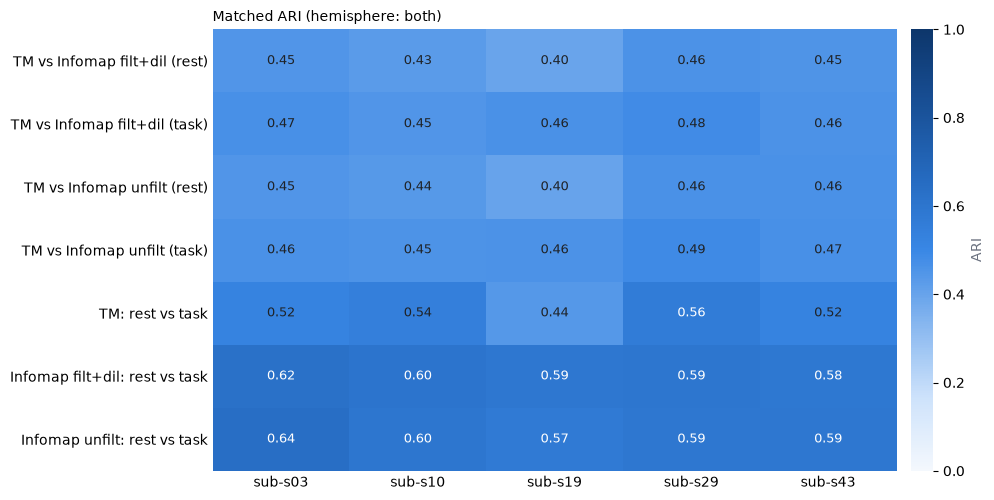

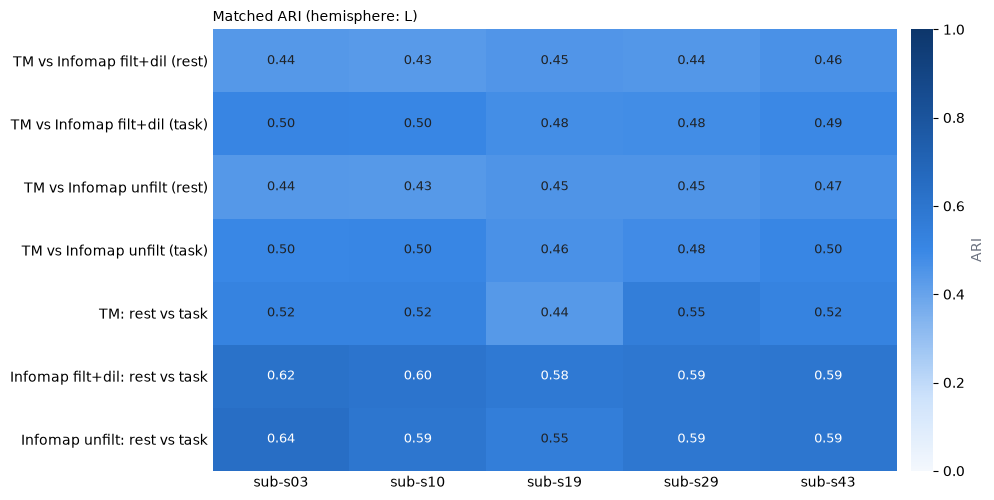

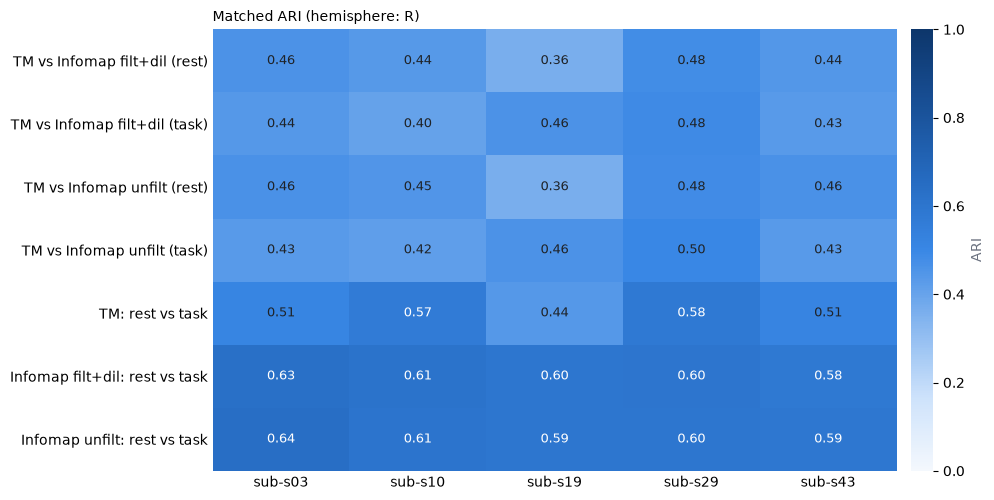

In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for hemi in ("both", "L", "R"):
    fig = plot_ari(ari, SUBJECTS, hemisphere=hemi)
    fig.savefig(OUTPUT_DIR / f"matched-ARI_hemi-{hemi}.png", dpi=150, facecolor="white")
    display(fig)
    plt.close(fig)

## 6. Confusion matrices: native TM × native Infomap

Rows are TM networks and columns are Infomap networks, ordered by shared class. Cells show the number of cortical vertices assigned to both the row's TM network and the column's Infomap network, using only vertices labeled in both maps. Colors represent raw counts, and every cell is annotated (including zeros). Outlined blocks are the matched shared classes, so mass outside the outlines is what lowers the matched ARI. Counts (CSV) and figures (PNG) are saved for every subject × condition × Infomap variant.

The Default (DMN) block includes TM Default Mode (1), Temporal Pole (13), MTL (14), and Parietal Occipital (16), matched to Infomap Default subnetworks (1–4). Native network rows remain separate within this shared block.

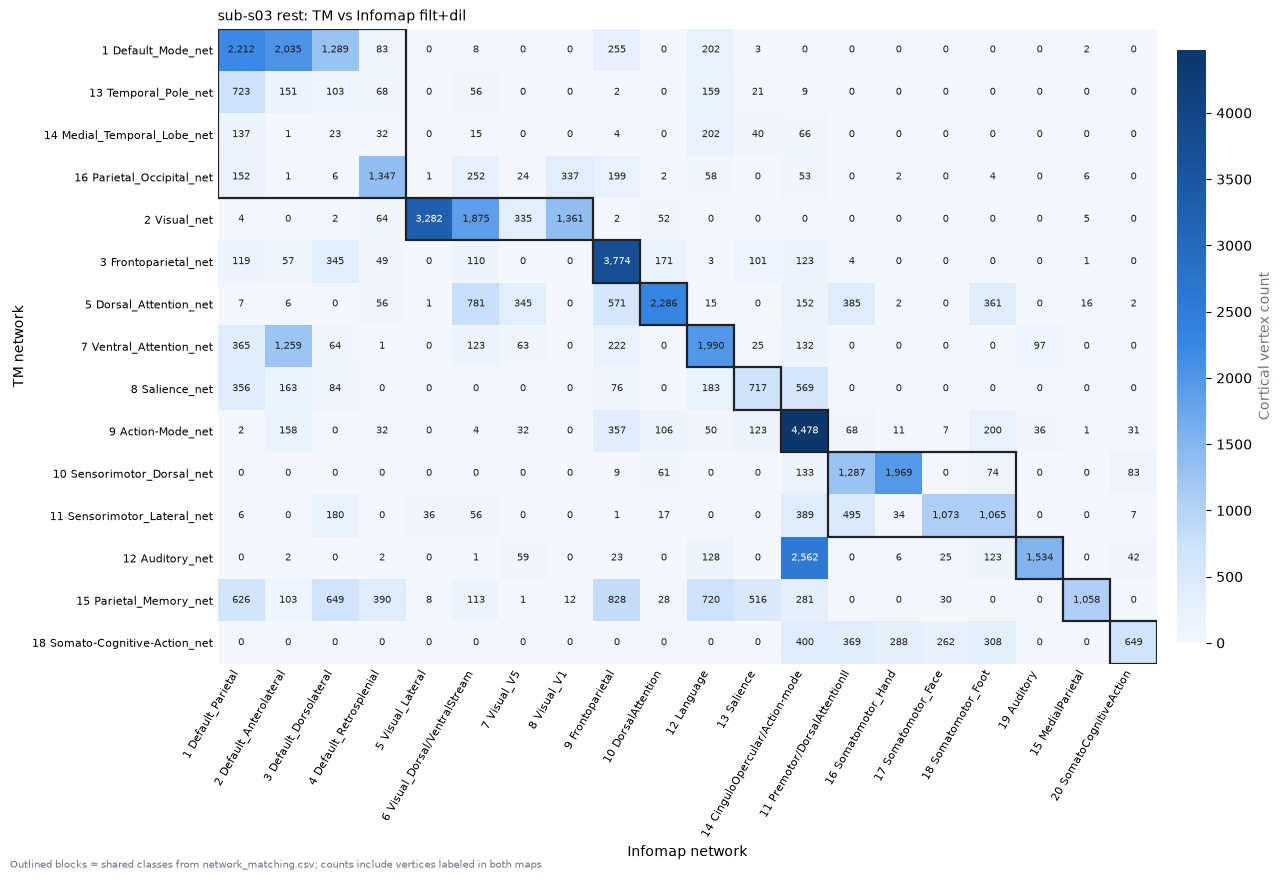

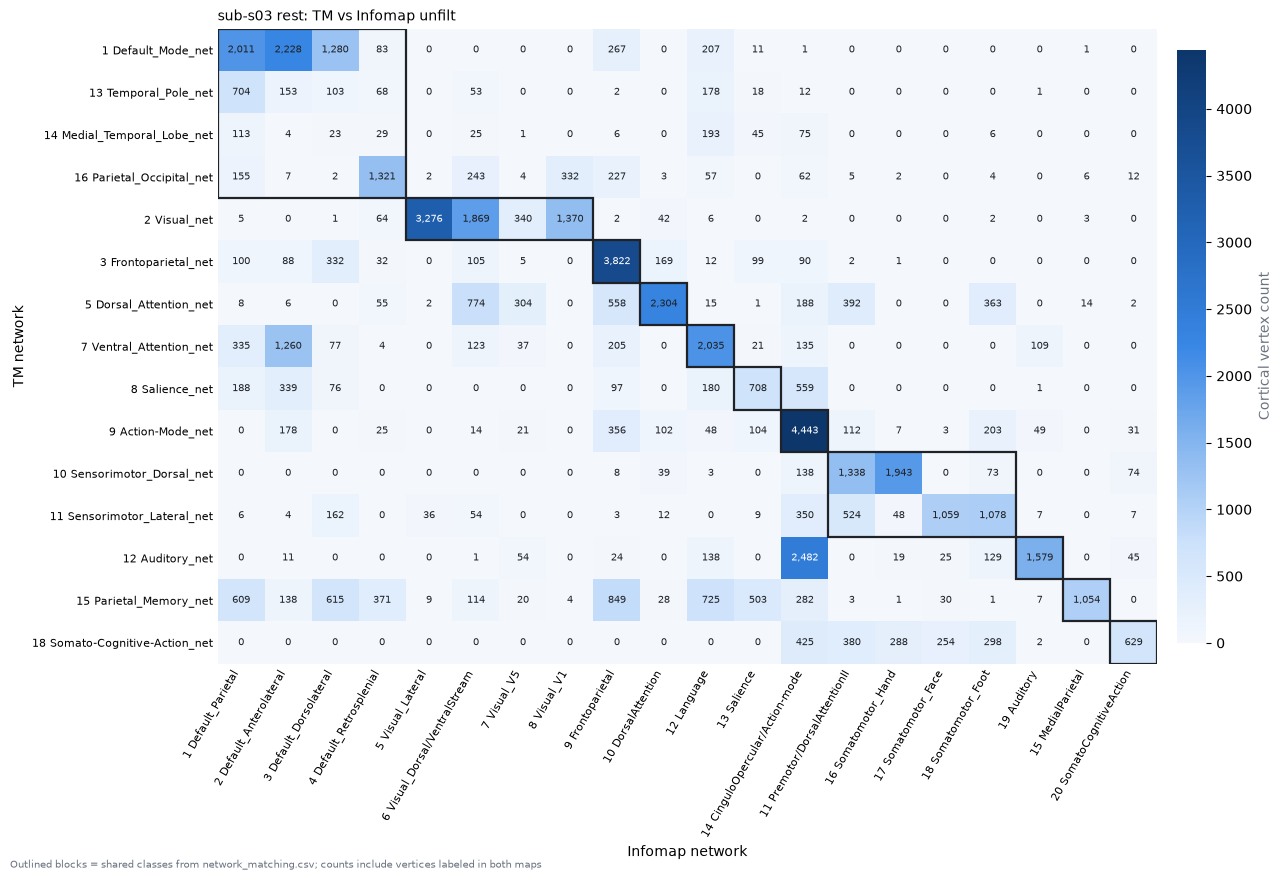

Saved confusion matrices to /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/01Oct2026_matched_ARI


In [7]:
for (subject, condition), case in cases.items():
    for infomap in ("Infomap", "Infomap unfiltered"):
        counts = native_confusion(case, matching, infomap)
        tag = "filtered-dilated" if infomap == "Infomap" else "unfiltered"
        stem = OUTPUT_DIR / f"sub-{subject}_task-{condition}_confusion_TM-vs-Infomap-{tag}"
        counts.to_csv(stem.with_suffix(".csv"))
        fig = plot_confusion(counts, f"sub-{subject} {condition}: TM vs {MAP_SHORT_NAMES[infomap]}")
        fig.savefig(stem.with_suffix(".png"), dpi=150, facecolor="white")
        if (subject, condition) in CONFUSION_DISPLAY:
            display(fig)
        plt.close(fig)
print(f"Saved confusion matrices to {OUTPUT_DIR}")

## 7. Save the ARI table and provenance

In [ ]:
ari.to_csv(OUTPUT_DIR / "matched-ARI.csv", index=False)
write_json(OUTPUT_DIR / "matched-ARI.json", provenance(SETTINGS, cases))
print(sorted(p.name for p in OUTPUT_DIR.iterdir() if not p.name.startswith("sub-")))

['matched-ARI.csv', 'matched-ARI.json', 'matched-ARI_hemi-L.png', 'matched-ARI_hemi-R.png', 'matched-ARI_hemi-both.png']
